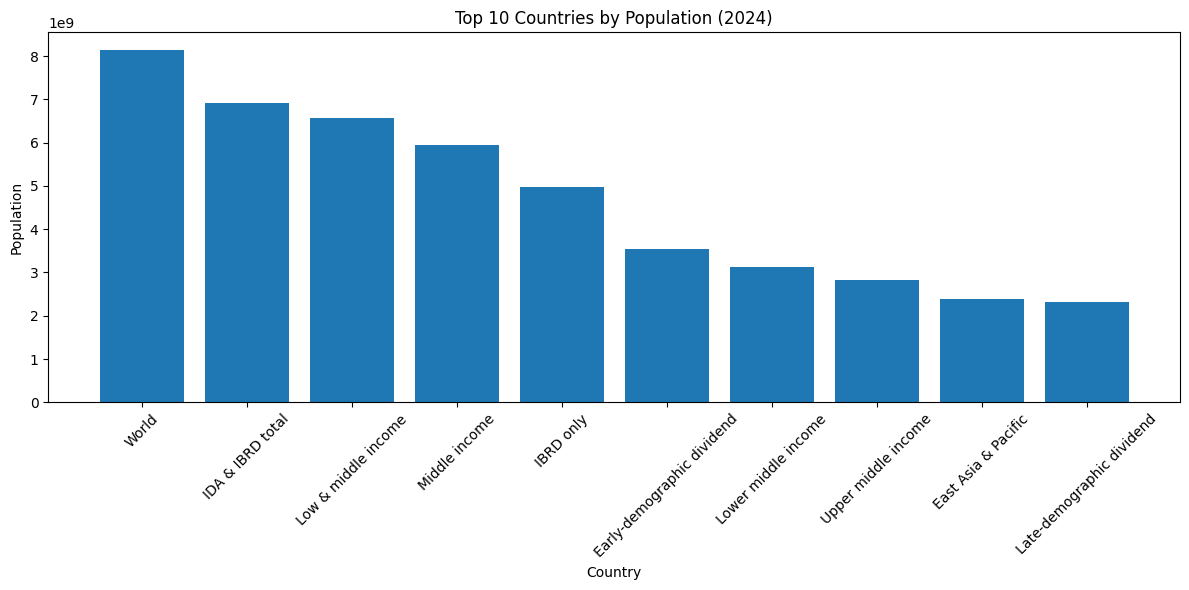

In [11]:
import zipfile
import pandas as pd
import matplotlib.pyplot as plt

# Define the correct path to the zip file
zip_file_path = "/content/API_SP.POP.TOTL_DS2_en_csv_v2_406129.zip"

# Extract zip
try:
    with zipfile.ZipFile(zip_file_path, "r") as zip_ref:
        zip_ref.extractall()
except FileNotFoundError:
    print(f"Error: The zip file '{zip_file_path}' was not found. Please ensure it's uploaded correctly.")
    raise
except Exception as e:
    print(f"An unexpected error occurred during zip extraction: {e}")
    raise

# Load MAIN dataset - The CSV is extracted to the current directory (/content/)
csv_file_name = "API_SP.POP.TOTL_DS2_en_csv_v2_406129.csv"
df = pd.read_csv(
    csv_file_name,
    skiprows=4
)

# Dynamically determine the latest year with non-missing population data
year_columns_candidates = [col for col in df.columns if isinstance(col, str) and col.isdigit() and len(col) == 4]

if not year_columns_candidates:
    print("Error: No 4-digit year columns found in the DataFrame to determine population data.")
    raise ValueError("No valid year columns found.")

# Sort years in descending order to find the latest with actual data
year_columns_candidates.sort(key=int, reverse=True)

found_latest_valid_year = None
for year_str in year_columns_candidates:
    # Check if the column exists and has at least one non-null value
    if year_str in df.columns and df[year_str].notna().any():
        found_latest_valid_year = year_str
        break

if found_latest_valid_year is None:
    print("Error: No year column found with non-missing population data.")
    raise ValueError("No valid year column with data found.")

latest_year = found_latest_valid_year

# Check if 'Country Name' column exists
if 'Country Name' not in df.columns:
    print("Error: 'Country Name' column not found in the DataFrame.")
    raise KeyError("'Country Name' column not found.")

# Use dynamically determined latest_year population data
top10 = df[['Country Name', latest_year]].dropna(subset=[latest_year])

# This warning should now ideally not be triggered if a valid year with data is found
# but kept as a safeguard
if top10.empty:
    print(f"Warning: No non-missing population data found for the year {latest_year}. The plot will be empty.")

top10 = top10.sort_values(
    by=latest_year,
    ascending=False
).head(10)

# Plot
plt.figure(figsize=(12,6))
plt.bar(top10['Country Name'], top10[latest_year])

plt.title(f"Top 10 Countries by Population ({latest_year})") # Update title dynamically
plt.xlabel("Country")
plt.ylabel("Population")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("population_distribution.png")
plt.show()